<a href="https://colab.research.google.com/github/Kaybee125-alt/CodeAlpha_Emotion_Recognition_from_Speech-/blob/main/Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Emotion Recognition from Speech**

#**Introduction**

**Objective**

The objective of this task is to develop a deep learning model capable of recognising seven human emotions—anger, boredom, disgust, fear, happiness, neutral, and sadness—from short speech recordings.

**Motivation**

Speech contains important emotional cues that can be reflected through characteristics such as pitch, energy, rhythm, and spectral patterns. The same words can therefore be expressed with different emotions depending on how they are spoken. Automatic emotion recognition from speech has potential applications in areas such as call-centre analytics, virtual assistants, mental-health monitoring, and human-computer interaction. The model therefore aims to learn relevant acoustic patterns from speech recordings rather than relying on the words themselves.

#**Data Description**


**Dataset:** The **EMO-DB (Berlin Database of Emotional Speech)** is a speech-emotion dataset consisting of `.wav` audio recordings. The dataset contains short German-language utterances performed by professional actors and provides seven emotion categories for classification.

| Property            | Description                                                          |
| ------------------- | -------------------------------------------------------------------- |
| **Recordings**      | 535 short speech utterances                                          |
| **Speakers**        | 10 professional actors (5 male and 5 female)                         |
| **Language**        | German, consisting of 10 different sentences                         |
| **Audio format**    | WAV, sampled at 16 kHz, with recordings of approximately 1–8 seconds |
| **Emotion classes** | 7                                                                    |
| **Labels**          | Encoded within the recording file names, e.g. `03a01Fa.wav`          |

#### File Naming Convention

The emotion labels are encoded in the recording file names. For example, in `03a01Fa.wav`:

* **Characters 1–2:** Speaker number (`03`)
* **Characters 3–5:** Sentence code (`a01`)
* **Character 6:** Emotion code (`F`)
* **Character 7:** Recording version (`a`)

The emotion codes and corresponding number of recordings are shown below:

| Code | Emotion   | Samples |
| ---- | --------- | ------: |
| W    | Anger     |     127 |
| L    | Boredom   |      81 |
| E    | Disgust   |      46 |
| A    | Fear      |      69 |
| F    | Happiness |      71 |
| T    | Sadness   |      62 |
| N    | Neutral   |      79 |

The dataset is **imbalanced**, with anger containing substantially more recordings than disgust. In addition, the overall dataset is relatively small. These characteristics can make the model more susceptible to overfitting and may affect its ability to learn minority emotion classes. Therefore, **dropout and early stopping** are incorporated into the CNN-LSTM training process to help improve generalisation.


#**Setup**

In [ ]:

import os
import glob
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import tensorflow as tf

from google.colab import files
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Librosa version:", librosa.__version__)

TensorFlow version: 2.20.0
Librosa version: 0.11.0


#**Manual upload of the EMO-DB zip file**

In [ ]:
print("Please upload your EMO-DB ZIP file.")

uploaded = files.upload()

# Get the uploaded file name
zip_name = next(iter(uploaded))

print("\nUploaded file:", zip_name)

# Check that the uploaded file is a ZIP file
if not zip_name.lower().endswith(".zip"):
    raise ValueError("Please upload the EMO-DB dataset as a .zip file.")

# Create a folder for the extracted dataset
extract_path = "/content/emodb"

os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Extraction folder:", extract_path)

Please upload your EMO-DB ZIP file.


Saving archive.zip to archive.zip

Uploaded file: archive.zip
Dataset extracted successfully.
Extraction folder: /content/emodb


#**Find all way audio files**

In [ ]:
# Search through all folders and subfolders
wav_files = sorted(
    glob.glob("/content/emodb/**/*.wav", recursive=True)
)

print("Number of WAV files found:", len(wav_files))

# Display a few example file paths
print("\nExample files:")
for path in wav_files[:5]:
    print(path)

# Check the expected EMO-DB size
if len(wav_files) == 535:
    print("\n✓ Expected 535 EMO-DB recordings were found.")
else:
    print(
        f"\n⚠ Found {len(wav_files)} recordings instead of 535. "
        "Check the uploaded ZIP file and folder structure."
    )

Number of WAV files found: 535

Example files:
/content/emodb/wav/03a01Fa.wav
/content/emodb/wav/03a01Nc.wav
/content/emodb/wav/03a01Wa.wav
/content/emodb/wav/03a02Fc.wav
/content/emodb/wav/03a02Nc.wav

✓ Expected 535 EMO-DB recordings were found.


#**Read emotion labels from file names**

In [ ]:
EMOTION_MAP = {
    "W": "anger",
    "L": "boredom",
    "E": "disgust",
    "A": "fear",
    "F": "happiness",
    "T": "sadness",
    "N": "neutral"
}

# Fixed class order
class_names = sorted(EMOTION_MAP.values())

# Convert emotion names into integer labels
label_to_idx = {
    emotion: index
    for index, emotion in enumerate(class_names)
}

# Create dataframe
df = pd.DataFrame({"path": wav_files})

# Extract emotion from the sixth character of the filename
df["emotion"] = df["path"].apply(
    lambda path: EMOTION_MAP[os.path.basename(path)[5]]
)

# Extract speaker ID
df["speaker"] = df["path"].apply(
    lambda path: os.path.basename(path)[:2]
)

# Convert emotion to numerical label
df["label"] = df["emotion"].map(label_to_idx)

print("Class order:")
print(class_names)

print("\nFirst five recordings:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Class order:
['anger', 'boredom', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']

First five recordings:


,path,emotion,speaker,label
0,/content/emodb/wav/03a01Fa.wav,happiness,03,4
1,/content/emodb/wav/03a01Nc.wav,neutral,03,5
2,/content/emodb/wav/03a01Wa.wav,anger,03,0
3,/content/emodb/wav/03a02Fc.wav,happiness,03,4
4,/content/emodb/wav/03a02Nc.wav,neutral,03,5



Missing values:
path       0
emotion    0
speaker    0
label      0
dtype: int64


#**Class distribution**

Number of recordings per emotion:
emotion
anger        127
boredom       81
disgust       46
fear          69
happiness     71
neutral       79
sadness       62
Name: count, dtype: int64


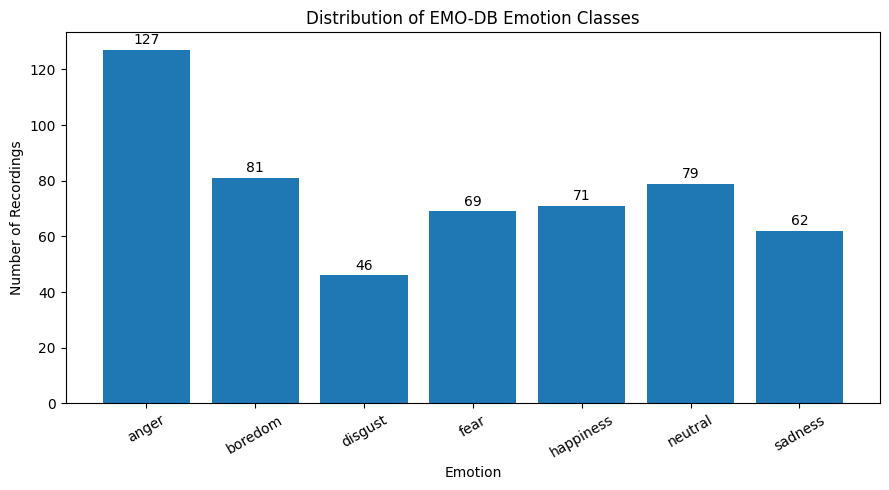

In [ ]:
counts = (
    df["emotion"]
    .value_counts()
    .reindex(class_names)
)

print("Number of recordings per emotion:")
print(counts)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title("Distribution of EMO-DB Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=30)

# Add values above bars
for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

#**Feature Extraction (MFCCs)**

In [47]:
if len(wav_files) == 0:
    raise ValueError(
        "No WAV files were found. Please check the uploaded ZIP file."
    )

print("First audio file:")
print(wav_files[0])

# Test loading one recording
test_audio, test_sr = librosa.load(
    wav_files[0],
    sr=16000
)

print("\nTest audio loaded successfully.")
print("Sampling rate:", test_sr)
print("Number of samples:", len(test_audio))
print("Duration:", round(len(test_audio) / test_sr, 2), "seconds")

First audio file:
/content/emodb/wav/03a01Fa.wav

Test audio loaded successfully.
Sampling rate: 16000
Number of samples: 30372
Duration: 1.9 seconds


In [48]:
SR = 16000
DURATION = 3
N_MFCC = 40
HOP = 512

MAX_LEN = SR * DURATION
MAX_FRAMES = 1 + MAX_LEN // HOP


def extract_mfcc(path):
    """
    Load one audio recording, standardise its length
    to 3 seconds, and extract 40 MFCC coefficients.
    """

    audio, _ = librosa.load(
        path,
        sr=SR
    )

    # Cut or zero-pad audio to exactly 3 seconds
    audio = librosa.util.fix_length(
        audio,
        size=MAX_LEN
    )

    # Extract MFCC features
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=N_MFCC,
        hop_length=HOP
    )

    # Transpose to:
    # time steps × MFCC coefficients
    return mfcc.T


# Extract MFCCs from all recordings
X = np.array([
    extract_mfcc(path)
    for path in df["path"]
])

y = df["label"].values

print("MFCC feature shape:", X.shape)
print("Label shape:", y.shape)

MFCC feature shape: (535, 94, 40)
Label shape: (535,)


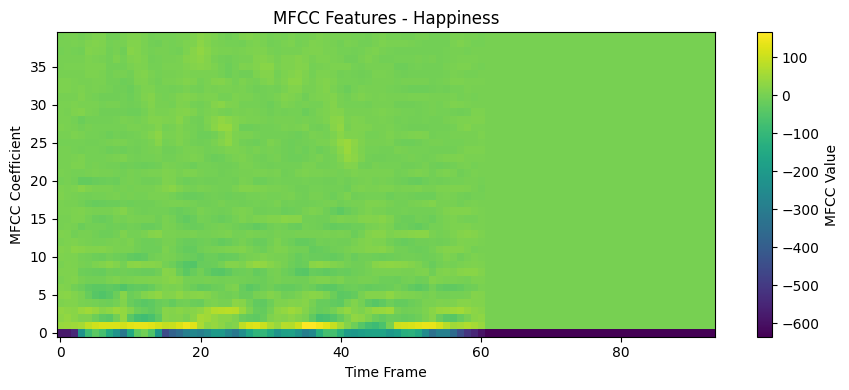

In [49]:
if X.ndim != 3 or X.shape[0] == 0:
    raise ValueError(
        f"Unexpected MFCC shape: {X.shape}"
    )

i = 0

plt.figure(figsize=(9, 4))

plt.imshow(
    X[i].T,
    aspect="auto",
    origin="lower"
)

plt.title(
    f"MFCC Features - {df.loc[i, 'emotion'].capitalize()}"
)

plt.xlabel("Time Frame")
plt.ylabel("MFCC Coefficient")

plt.colorbar(label="MFCC Value")

plt.tight_layout()
plt.show()

#**Train / Validation / Test Split and Scaling**

In [51]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Standardise each MFCC coefficient (mean 0, std 1) using training data only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("Train:", X_train.shape, "| Validation:", X_val.shape, "| Test:", X_test.shape)

Train: (374, 94, 40) | Validation: (80, 94, 40) | Test: (81, 94, 40)


#**Model Architecture (CNN-LSTM)**

In [52]:
model = models.Sequential([
    layers.Input(shape=(MAX_FRAMES, N_MFCC)),

    layers.Conv1D(64, 5, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),

    layers.Conv1D(128, 5, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),

    layers.LSTM(64),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax"),
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 94, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 94, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 47, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,743 (424.78 KB)

 Trainable params: 108,359 (423.28 KB)

 Non-trainable params: 384 (1.50 KB)

#**Training**

In [53]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2353 - loss: 1.8977 - val_accuracy: 0.3500 - val_loss: 1.8058
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3824 - loss: 1.6778 - val_accuracy: 0.3250 - val_loss: 1.6501
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4412 - loss: 1.5010 - val_accuracy: 0.3375 - val_loss: 1.5217
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5267 - loss: 1.3194 - val_accuracy: 0.4000 - val_loss: 1.3767
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5535 - loss: 1.1422 - val_accuracy: 0.4375 - val_loss: 1.2405
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6578 - loss: 0.9865 - val_accuracy: 0.5500 - val_loss: 1.1106
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7032 - loss: 0.8501 - val_accuracy: 0.5750 - val_loss: 1.0730
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7567 - loss: 0.7462 - val_accuracy: 0.

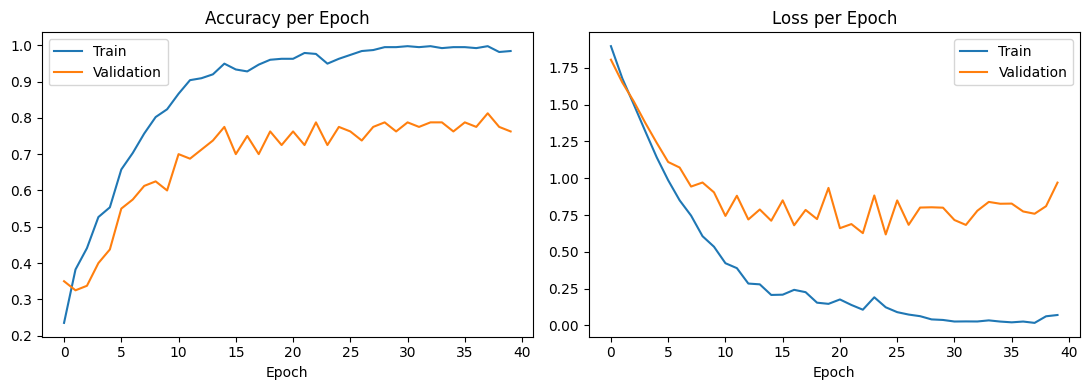

In [54]:
# Learning curves
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy per Epoch"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss per Epoch"); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.show()

#**Evaluation**

In [55]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.6420
              precision    recall  f1-score   support

       anger       0.75      0.95      0.84        19
     boredom       0.50      0.33      0.40        12
     disgust       1.00      0.43      0.60         7
        fear       0.67      0.55      0.60        11
   happiness       0.71      0.45      0.56        11
     neutral       0.62      0.67      0.64        12
     sadness       0.47      0.89      0.62         9

    accuracy                           0.64        81
   macro avg       0.67      0.61      0.61        81
weighted avg       0.67      0.64      0.63        81



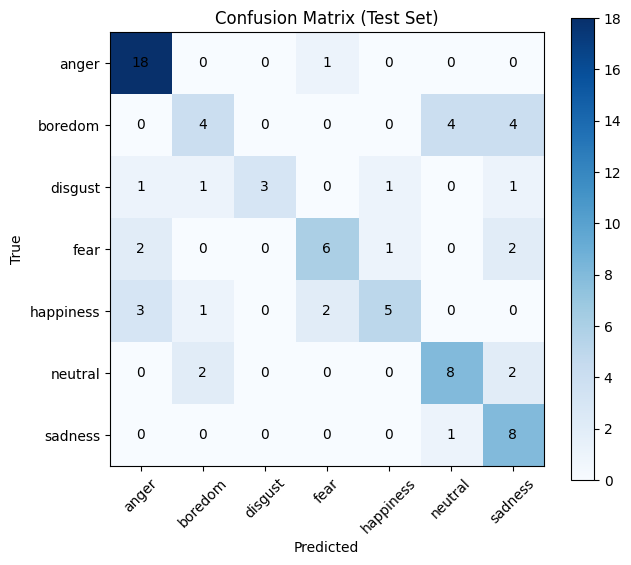

In [56]:
# Confusion matrix: rows = true emotion, columns = predicted emotion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        plt.text(c, r, cm[r, c], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()
plt.show()

#**Predict a Single Recording and Save the Model**

In [57]:
def predict_emotion(path):
    feats = (extract_mfcc(path)[np.newaxis] - mean) / std
    probs = model.predict(feats, verbose=0)[0]
    return class_names[np.argmax(probs)], probs.max()

emotion, confidence = predict_emotion(df["path"][0])
print(f"Predicted: {emotion} ({confidence:.2%}) | True: {df['emotion'][0]}")

model.save("emodb_emotion_model.keras")

Predicted: happiness (98.73%) | True: happiness


#**Conclusion**

**Summary**

A CNN-LSTM model was trained using MFCC features extracted from the EMO-DB speech recordings to classify seven different emotions. The dataset was divided using stratified sampling to maintain a similar class distribution across the subsets. The MFCC features were standardised using statistics calculated from the training set only, thereby preventing data leakage. The model was then evaluated on unseen test recordings using accuracy, a per-class classification report, and a confusion matrix.

**Findings**

* The MFCC features contained sufficient acoustic information for the CNN-LSTM model to learn meaningful emotional patterns and perform clearly above the approximately 14% chance level expected for a seven-class classification problem. The exact performance values are reported from the individual model run.
* Emotions with stronger and more distinctive acoustic characteristics, such as **anger**, tend to be recognised more reliably. In contrast, emotions with more similar acoustic characteristics, particularly **boredom, neutral, and sadness**, are more likely to be confused with one another, as reflected in the confusion matrix.
* The difference between the training and validation learning curves provides an indication of the model's degree of overfitting. This is understandable given the relatively small size of the dataset and the complexity of the CNN-LSTM architecture.

**Limitations**

* The EMO-DB dataset contains only **535 recordings**, which limits the amount of training data available and means that performance can vary depending on the random train-validation-test split.
* The data were split at the recording level rather than the speaker level. Consequently, recordings from the same actor may occur in both the training and test sets. Therefore, the reported performance may not fully represent how the model would perform when recognising emotions from completely unseen speakers.
* The recordings consist of **acted German-language speech** collected under controlled conditions. As a result, the findings may not generalise directly to spontaneous speech, different languages, accents, or real-world recording environments.
